In [1]:
from resources.imports import *
from openpyxl import load_workbook

from resources.lattices import Geometry, pStrainProperties, effProperties
from resources.calculations import get_ductileData, get_fractureData, calcUT, calcFT, plot_curve

In [2]:
LAT = "tri"
MODEL = "both"
l = 0.010    # m      (# A:0.001260 B:0.001455 C:0.001262 D:0.001459)
t = None    # m      (# A:0.000203 B:0.000203 C:0.000152 D:0.000127)
rD = 0.2
material = "Ti"
dis = 'per'
dn = 0.2
nSim = '1'

nnx = 30 if LAT.lower() == "tri" else 20
nnx = nnx
iso = True if LAT.lower() in ["tri", "kagome", "hex"] else False
if material.lower() == "ti":
    E_s = 123e9  ## Pa
    v_s = 0.3
    s_ts, s_ys = 1111792033, 932000000  ## Pa 
elif material.lower() == "sic":
    E_s = 410e9  ## Pa
    v_s = 0.14
    s_ts, s_ys = 550000000, 550000000  ## Pa 

if dis == "per":
    dn = ""

val = False
psc = False
mesh = False

data  =  False
PATH_ADD = "sApp"

if data:
    os.chdir(f"Z:\\p1\\data\\{material}\\{dis}\\{PATH_ADD}\\{dn}\\{LAT}")
else:
    os.chdir(f"Z:\\p1\\sims\\{material}\\{PATH_ADD}")
    # os.chdir(r"C:\temp")

if val:
    os.chdir(f"Z:\\p1\\sims\\{material}\\sApp") #validation\\old\\{str(int(l*1000))}\\{str(rD)}")
    dis, nSim = 'per', '1'
elif psc:
    os.chdir(f"Z:\\p1\\sims\\{material}\\PSC\\{str(int(l*1000))}")
    dis, nSim = 'per', '1'
elif mesh:
    brackets = 1
    coarse = 1
    fine = 1
    os.chdir(f"Z:\\p1\\sims\\{material}\MeshConv\\{brackets}-{coarse}-{fine}")
    dis, nSim = 'per', '1'

In [3]:
# ## CONVERGENCE STUDIES

# sim = 20

# start_row = 94
# cell_row = start_row + sim

# sheet_name = "PSC"
# column = ["G", "H", "I", "K", "L", "M", "N"]

# nnxs = [10, 16, 20, 26, 30, 36, 40]
# nnx = nnxs[sim]


# sheet_name = "MeshConv"
# column = ["K", "L", "M", "O", "P", "Q", "R"]

# coarses = [1, 2, 5]
# fines = [1, 2, 5, 10 ,15, 20, 25]

# coarse = coarses[sim//len(fines)]
# fine = fines[sim%len(fines)]

# os.chdir(r"Z:\\p1\\sims\\Ti\MeshConv\\1-"+str(coarse)+"-"+str(fine))

In [4]:
geom = Geometry(LAT, l, nnx, t=t)
geom.FTcalc()

rD = geom.rD
E_eff, v_eff, E_eff_pe, v_eff_pe = effProperties(LAT, geom, E_s=E_s, v_s=v_s, rD=rD)
print(E_eff, v_eff, E_eff_pe, v_eff_pe)

if LAT.lower() == "45square":
    S = (1/E_s) * np.array([
        [0.5*(l/t) + 0.5*(l/t)**3, 0.5*(l/t) - 0.5*(l/t)**3 + 0.0000001, 0],
        [0.5*(l/t) - 0.5*(l/t)**3, 0.5*(l/t) + 0.5*(l/t)**3, 0],
        [0, 0, 2*(l/t)]
    ])
    C = np.linalg.inv(S)
elif LAT.lower() == "square":
    S = np.array([[1/E_eff, -v_eff/E_eff, 0],
                [-v_eff/E_eff, 1/E_eff, 0],
                [0, 0, 1/(E_s*(1/16)*(rD**3))]])
    C = np.linalg.inv(S)
    C=C
else:
    C = None

E_eff, v_eff, E_eff_pe, v_eff_pe = effProperties(LAT, geom, E_s=E_s, v_s=v_s, rD=rD, C=C, ortho=not iso)
print(E_eff, v_eff, E_eff_pe, v_eff_pe)

8200000000.0 0.3333333333333333 8453608247.422681 0.37457044673539514
8200000000.0 0.3333333333333333 8453608247.422681 0.37457044673539514


In [5]:
os.getcwd(), rD, iso

('Z:\\p1\\sims\\Ti\\sApp', 0.2, True)

In [6]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both": 
    CSVout = f"transfer\OUT-Ductile-{LAT}-{int(nnx)}-{dis}-{nSim}.csv"
    UTdf = get_ductileData(CSVout, crit=0.25)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    CSVout = f"transfer\OUT-Fracture-{LAT}-{int(nnx)}-{dis}-{nSim}.csv"
    FTdf = get_fractureData(CSVout)

In [7]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    ductility, strength, stiffness, WoF = calcUT(UTdf)
    print("DUCT:", ductility, strength, stiffness, WoF, "\n")

if MODEL.lower() == "fracture" or MODEL.lower() == "both":    
    P, dd, Ks, Kjs = calcFT(FTdf, geom, E_eff_pe,  n_Ks=1, iso=iso, validation=False, E=E_s, C=C)
    Kic, Kjic = Ks[0], Kjs[0]
    print("FRAC:", P, dd, Kic/1e6, Kjic/1e6, Kic/(s_ts*np.sqrt(l)), Kjic/(s_ts*np.sqrt(l)))

DUCT: 0.06489930725097656 75.24150737268522 8660.137686822149 4.47887701703852 

FRAC: 165839.1 0.01021484375 33.80958338611188 47.06674251591107 0.3040998890312419 0.42334124655407623


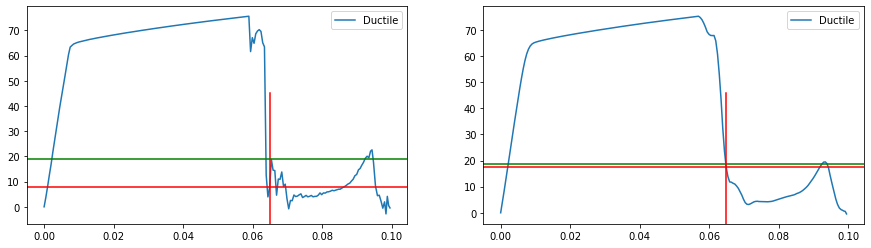

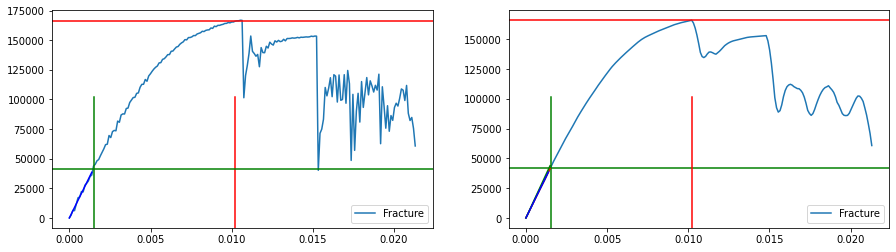

In [8]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    plot_curve([UTdf], typ="ut", label="Ductile")

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    plot_curve([FTdf], typ="ft", label="Fracture")

In [9]:
# ### WRITE TO EXCEL

# file_path = "C:/Users/exy053/OneDrive - Queen Mary, University of London/Documents/Research/p1-LatticeFractureToughness/Ductility-FractureToughness.xlsx"
# cell_coords = [f"{column[0]}{cell_row}", f"{column[1]}{cell_row}", f"{column[2]}{cell_row}", f"{column[3]}{cell_row}", f"{column[4]}{cell_row}", f"{column[5]}{cell_row}", f"{column[6]}{cell_row}"]
# values_to_write = [stiffness, strength, ductility, P, dd, Kic/(10**6), Kjic/(10**6)]

# # --- Load workbook and target sheet ---
# wb = load_workbook(file_path)
# ws = wb[sheet_name]

# # --- Write values ---
# for coord, value in zip(cell_coords, values_to_write):
#     ws[coord] = value
    
# # --- Save workbook ---
# wb.save(file_path)
# wb.close()

In [10]:
# ### SIM COMPARISON

# append = True
# appendReset = False
# if appendReset:
#     UTsave, FTsave = [], []

# if MODEL.lower() == "ductile" or MODEL.lower() == "both":
#     if append:
#         UTsave.append([UTdf, ductility, strength, stiffness])
#         plot_curve(np.array(UTsave, dtype=object)[:,0], typ="UT")


# if MODEL.lower() == "fracture" or MODEL.lower() == "both":
#     if append:
#         FTsave.append([FTdf, P, dd, Ks, Kjs])
#         plot_curve(np.array(FTsave, dtype=object)[:,0], typ="FT")

In [11]:
# ### NORMALIZATION of Ks

# s_ts = (932*(1+(0.1105-(932/123000))**0.7237)) * 10**6  # 

# K_norm = Kic/(s_ts)
# K_norml = Kic/(s_ts*((l)**0.5))
# Kj_norm = Kjic/(s_ts)
# Kj_norml = Kjic/(s_ts*((l)**0.5))

# K_norm, K_norml, Kj_norm, Kj_norml